# Phase 1 결과 분석

단일 출력 회귀 실험 — 설계문서 기준 모델별 FS 할당
- Ridge/Lasso/SVR/RF/XGB/LGB/CatBoost: FS1 + FS2
- GP: FS2만
- MLP: FS1만

In [6]:
import sys, os, json
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def _set_korean_font():
    candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic']
    available = {f.name for f in fm.fontManager.ttflist}
    for c in candidates:
        if c in available:
            matplotlib.rcParams['font.family'] = c
            break
    matplotlib.rcParams['axes.unicode_minus'] = False

_set_korean_font()

from pathlib import Path
RESULTS = Path(PROJECT_ROOT) / 'results'

TARGETS = ['Tc_K', 'Pc_MPa', 'omega']
MODEL_ORDER = ['Ridge','Lasso','SVR_Linear','SVR_RBF','GP',
               'RandomForest','XGBoost','LightGBM','CatBoost','MLP_sklearn','TabNet',
               'GCN','GAT','GIN','AttentiveFP'
               ]
COLORS = {'FS1': 'steelblue', 'FS2': 'darkorange'}
print('준비 완료')

준비 완료


## 1. 데이터 로드

In [7]:
cv   = pd.read_csv(RESULTS / 'cv_scores' / 'phase1_cv_summary.csv')
test = pd.read_csv(RESULTS / 'cv_scores' / 'phase1_test_summary.csv')

cv['model']   = pd.Categorical(cv['model'],   categories=MODEL_ORDER, ordered=True)
test['model'] = pd.Categorical(test['model'], categories=MODEL_ORDER, ordered=True)
cv   = cv.sort_values(['target','model','fs']).reset_index(drop=True)
test = test.sort_values(['target','model','fs']).reset_index(drop=True)

print(f'CV rows: {len(cv)}  Test rows: {len(test)}')
print('모델×FS 조합:', cv.groupby(['model','fs']).size().reset_index(name='n_targets').to_string(index=False))

CV rows: 240  Test rows: 240
모델×FS 조합:        model     fs  n_targets
       Ridge    FS1          3
       Ridge    FS2          3
       Ridge FS3_el          3
       Ridge FS3_gc          3
       Ridge FS3_gt          3
       Ridge FS3_lg          3
       Ridge FS3_rf          3
       Ridge    FS4          0
       Lasso    FS1          3
       Lasso    FS2          3
       Lasso FS3_el          3
       Lasso FS3_gc          3
       Lasso FS3_gt          3
       Lasso FS3_lg          3
       Lasso FS3_rf          3
       Lasso    FS4          0
  SVR_Linear    FS1          3
  SVR_Linear    FS2          3
  SVR_Linear FS3_el          3
  SVR_Linear FS3_gc          3
  SVR_Linear FS3_gt          3
  SVR_Linear FS3_lg          3
  SVR_Linear FS3_rf          3
  SVR_Linear    FS4          0
     SVR_RBF    FS1          3
     SVR_RBF    FS2          3
     SVR_RBF FS3_el          3
     SVR_RBF FS3_gc          3
     SVR_RBF FS3_gt          3
     SVR_RBF FS3_lg          3


C:\Users\user\AppData\Local\Temp\ipykernel_9928\1352294563.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print('모델×FS 조합:', cv.groupby(['model','fs']).size().reset_index(name='n_targets').to_string(index=False))


## 2. FS2 선택된 feature 확인

In [8]:
with open(RESULTS / 'shap' / 'fs2_features.json') as f:
    fs2_data = json.load(f)

print(f"FS2 feature 수: {len(fs2_data['features'])}개")
print("\nTop-20:")
for i, feat in enumerate(fs2_data['features'][:20], 1):
    print(f"  {i:2d}. {feat}")

FS2 feature 수: 50개

Top-20:
   1. el_polarizability
   2. el_molMR
   3. el_q_min
   4. gt_ipc
   5. gc_sum_dTc
   6. rf_type_other
   7. el_dipole_gasteiger
   8. gt_mw
   9. el_logP
  10. el_en_mean
  11. el_tpsa
  12. gt_n_arom
  13. gc_CH3
  14. el_en_std
  15. gt_n_C
  16. gt_exact_mw
  17. lg_mean_num_Hs
  18. el_q_mean
  19. gc_sum_dPc
  20. lg_mean_is_in_ring


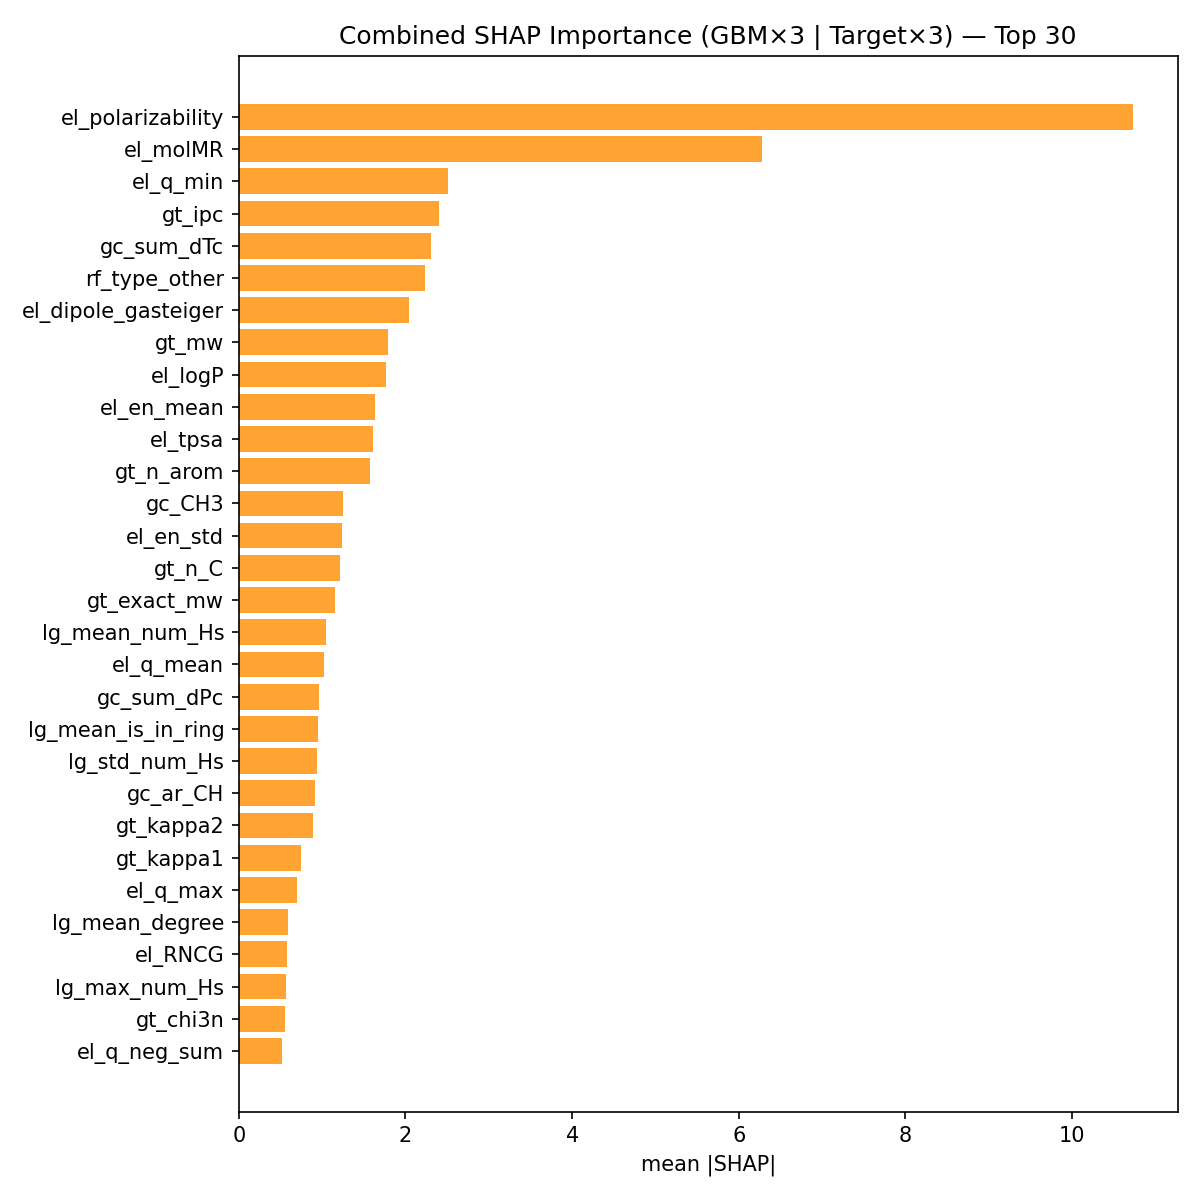

In [9]:
# Combined SHAP importance 시각화
from IPython.display import Image
Image(str(RESULTS / 'shap' / 'combined_shap_top30.png'))

## 3. CV RMSE 비교 (FS1 vs FS2, 타겟별)

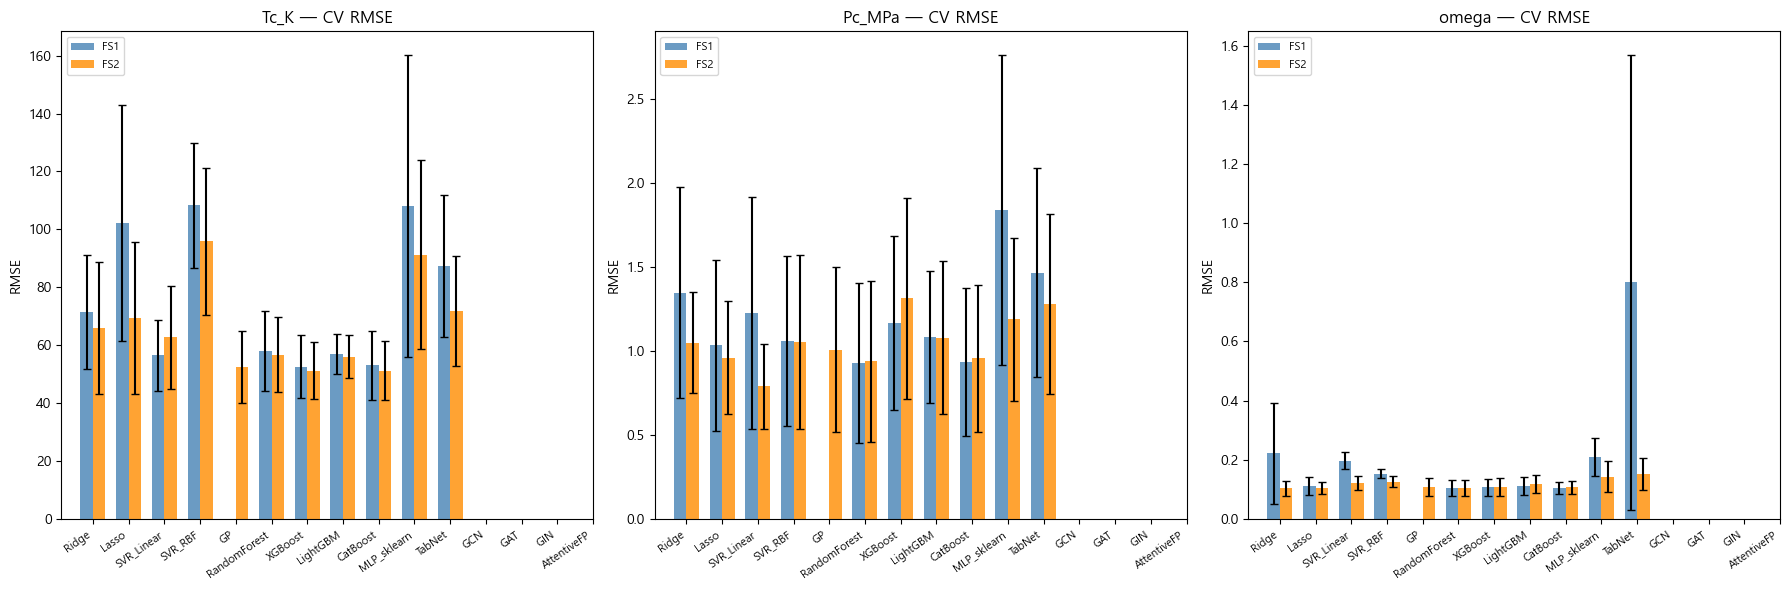

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tgt in zip(axes, TARGETS):
    sub = cv[cv['target'] == tgt].sort_values(['model','fs'])
    models_avail = sub['model'].unique()
    x = np.arange(len(models_avail))

    for i, fs in enumerate(['FS1', 'FS2']):
        fs_sub = sub[sub['fs'] == fs].set_index('model')
        vals  = [fs_sub.loc[m, 'cv_rmse_mean'] if m in fs_sub.index else np.nan for m in models_avail]
        errs  = [fs_sub.loc[m, 'cv_rmse_std']  if m in fs_sub.index else 0       for m in models_avail]
        w = 0.35
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, w, yerr=errs, label=fs,
               color=COLORS[fs], alpha=0.8, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(models_avail, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{tgt} — CV RMSE')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_cv_rmse_fs1_vs_fs2.png', dpi=150)
plt.show()

## 4. Test RMSE 비교 (FS1 vs FS2)

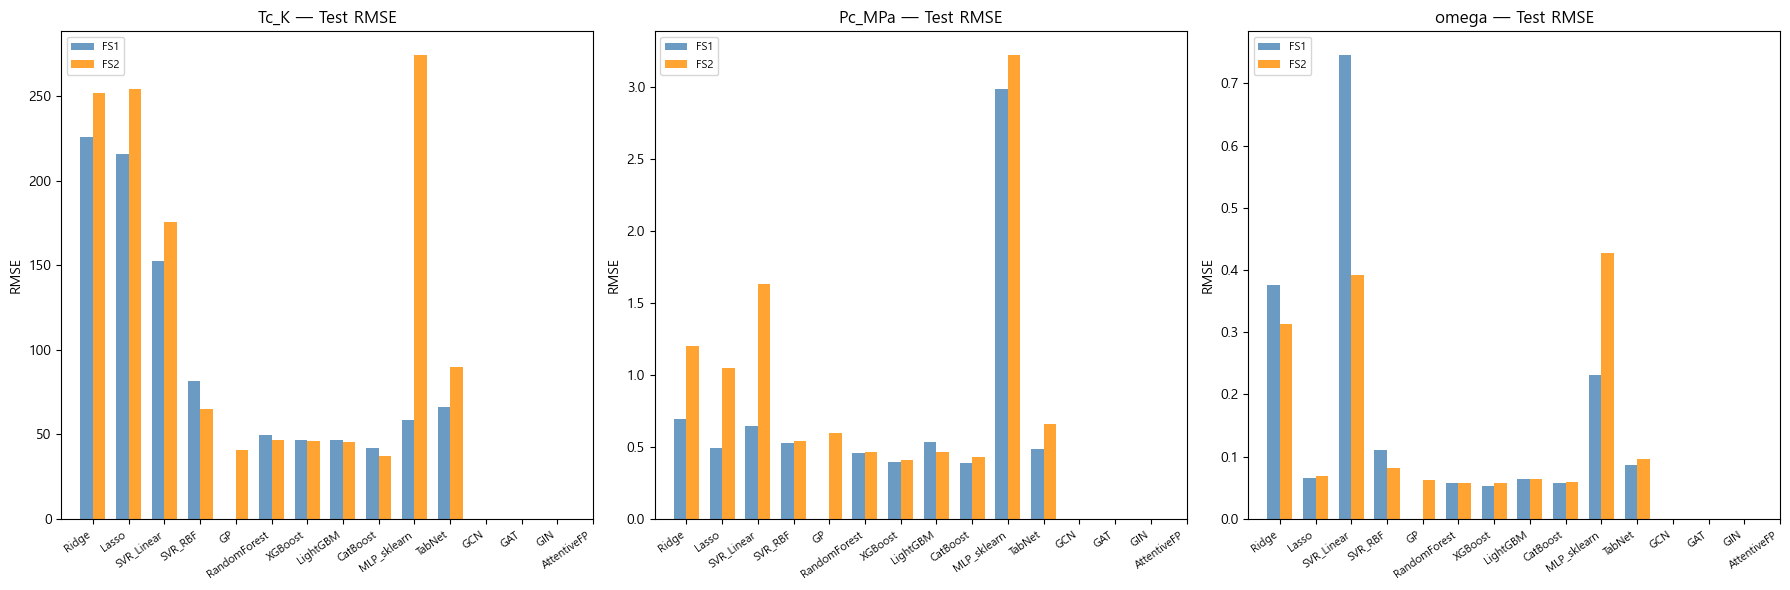

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tgt in zip(axes, TARGETS):
    sub = test[test['target'] == tgt]
    models_avail = [m for m in MODEL_ORDER if m in sub['model'].values]
    x = np.arange(len(models_avail))

    for i, fs in enumerate(['FS1', 'FS2']):
        fs_sub = sub[sub['fs'] == fs].set_index('model')
        vals = [fs_sub.loc[m, 'rmse'] if m in fs_sub.index else np.nan for m in models_avail]
        w = 0.35
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, w, label=fs, color=COLORS[fs], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(models_avail, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{tgt} — Test RMSE')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_test_rmse_fs1_vs_fs2.png', dpi=150)
plt.show()

## 5. CV R² 비교

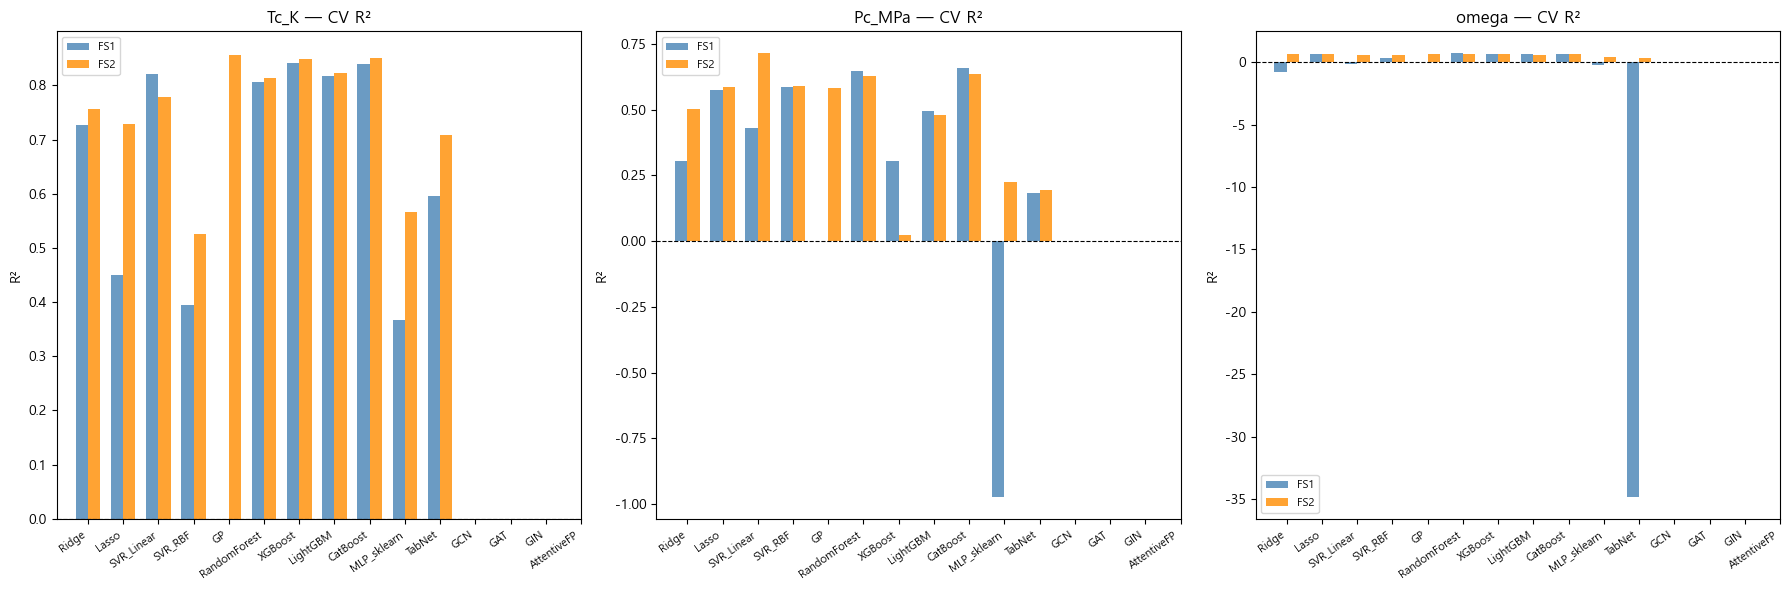

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tgt in zip(axes, TARGETS):
    sub = cv[cv['target'] == tgt]
    models_avail = [m for m in MODEL_ORDER if m in sub['model'].values]
    x = np.arange(len(models_avail))

    for i, fs in enumerate(['FS1', 'FS2']):
        fs_sub = sub[sub['fs'] == fs].set_index('model')
        vals = [fs_sub.loc[m, 'cv_r2_mean'] if m in fs_sub.index else np.nan for m in models_avail]
        w = 0.35
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, w, label=fs, color=COLORS[fs], alpha=0.8)

    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(models_avail, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{tgt} — CV R²')
    ax.set_ylabel('R²')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_cv_r2.png', dpi=150)
plt.show()

## 6. 통합 성능 요약표 (Test 기준)

In [13]:
pivot_rows = []
for _, row in test.iterrows():
    pivot_rows.append({
        'model': row['model'],
        'fs':    row['fs'],
        'target': row['target'],
        'rmse':  round(row['rmse'], 4),
        'r2':    round(row['r2'], 4),
        'mape':  f"{row['mape']:.2f}%",
    })

summary = pd.DataFrame(pivot_rows)
# 타겟별 wide format
for tgt in TARGETS:
    print(f"\n{'='*60}")
    print(f" {tgt}")
    print('='*60)
    sub = summary[summary['target'] == tgt].drop(columns='target').sort_values(['model','fs'])
    print(sub.to_string(index=False))


 Tc_K
       model     fs     rmse      r2   mape
 AttentiveFP    FS4 118.6161 -0.0770 21.26%
    CatBoost    FS1  42.1105  0.8643  5.59%
    CatBoost    FS2  37.4102  0.8929  4.99%
    CatBoost FS3_el  42.0241  0.8648  6.34%
    CatBoost FS3_gc  45.5691  0.8410  5.81%
    CatBoost FS3_gt  47.6144  0.8265  6.71%
    CatBoost FS3_lg  49.3034  0.8139  7.55%
    CatBoost FS3_rf  55.0873  0.7677  7.19%
         GAT    FS4  48.0377  0.8234  7.56%
         GCN    FS4  79.3281  0.5183  9.98%
         GIN    FS4  58.1068  0.7415  9.41%
          GP    FS2  40.6656  0.8734  5.33%
          GP FS3_el  32.9556  0.9169  4.70%
          GP FS3_gc  53.8048  0.7784  6.24%
          GP FS3_gt  48.0251  0.8234  6.69%
          GP FS3_lg  42.6107  0.8610  6.27%
          GP FS3_rf 115.3946 -0.0193 20.11%
       Lasso    FS1 215.6005 -2.5583 10.13%
       Lasso    FS2 254.2291 -3.9476 11.94%
       Lasso FS3_el  47.3367  0.8285  7.35%
       Lasso FS3_gc  57.5164  0.7468  7.05%
       Lasso FS3_gt 158.8

## 7. 최고 성능 모델 (타겟 × FS 기준)

In [14]:
print('=== Test RMSE 기준 최고 모델 (타겟별) ===')
for tgt in TARGETS:
    sub = test[test['target'] == tgt].sort_values('rmse')
    best = sub.iloc[0]
    print(f"  {tgt:8s}: {best['model']:15s} ({best['fs']})  "
          f"RMSE={best['rmse']:.4f}  R²={best['r2']:.4f}  MAPE={best['mape']:.2f}%")

print()

# Mean MAPE 기준 종합 순위
mean_mape = (
    test.groupby(['model','fs'])['mape'].mean()
    .reset_index()
    .rename(columns={'mape': 'mean_mape_3targets'})
    .sort_values('mean_mape_3targets')
)
print('=== Mean MAPE 기준 종합 순위 (3타겟 평균) ===')
print(mean_mape.to_string(index=False))

=== Test RMSE 기준 최고 모델 (타겟별) ===
  Tc_K    : GP              (FS3_el)  RMSE=32.9556  R²=0.9169  MAPE=4.70%
  Pc_MPa  : CatBoost        (FS1)  RMSE=0.3860  R²=0.9037  MAPE=6.15%
  omega   : XGBoost         (FS1)  RMSE=0.0536  R²=0.8305  MAPE=15.39%

=== Mean MAPE 기준 종합 순위 (3타겟 평균) ===
       model     fs  mean_mape_3targets
     XGBoost    FS1            9.524353
    CatBoost    FS1            9.576024
          GP FS3_el            9.845910
    LightGBM    FS2           10.048351
     XGBoost    FS2           10.452492
    LightGBM    FS1           10.692329
    CatBoost FS3_el           11.071516
    CatBoost    FS2           11.399945
     XGBoost FS3_el           11.636764
          GP    FS2           11.705879
          GP FS3_lg           12.136324
RandomForest    FS1           12.369960
RandomForest    FS2           12.425639
     XGBoost FS3_gt           12.613243
    LightGBM FS3_el           12.852769
    LightGBM FS3_lg           13.211542
     XGBoost FS3_lg           13.42

C:\Users\user\AppData\Local\Temp\ipykernel_9928\3730838783.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test.groupby(['model','fs'])['mape'].mean()


## 8. Parity Plots — 타겟별 최고 모델 (OOF CV)

> 그래프 안 지표는 OOF 전체 배열로 직접 계산한 값.  
> 위 셀 "최고 모델" 지표는 **Test set** 기준이므로 다른 것이 정상.

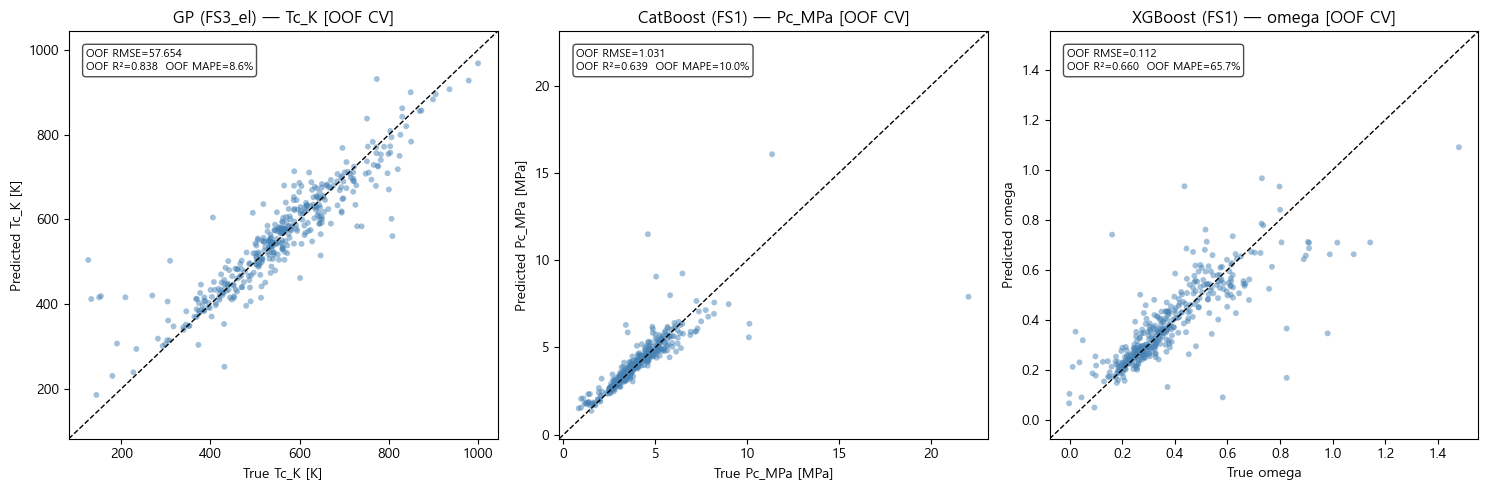

(참고) Test set 성능:
  Tc_K: GP(FS3_el)  Test RMSE=32.9556  R²=0.9169  MAPE=4.70%
  Pc_MPa: CatBoost(FS1)  Test RMSE=0.3860  R²=0.9037  MAPE=6.15%
  omega: XGBoost(FS1)  Test RMSE=0.0536  R²=0.8305  MAPE=15.39%


In [35]:
from sklearn.metrics import r2_score

def oof_metrics(y_true, y_pred, target):
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)
    r2   = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

# 타겟별 Test RMSE 최소 (model, fs) 찾기
best_combos = {}
for tgt in TARGETS:
    sub = test[test['target'] == tgt].sort_values('rmse')
    best_combos[tgt] = (sub.iloc[0]['model'], sub.iloc[0]['fs'])

units = {'Tc_K': 'K', 'Pc_MPa': 'MPa', 'omega': ''}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tgt in zip(axes, TARGETS):
    m, fs = best_combos[tgt]
    json_path = RESULTS / 'cv_scores' / f'{m}_{fs}_{tgt}.json'
    with open(json_path) as f:
        result = json.load(f)

    y_true = np.array(result['oof_true'])
    y_pred = np.array(result['oof_pred'])
    # OOF 전체 배열로 직접 계산 (fold 평균 아님)
    mm = oof_metrics(y_true, y_pred, tgt)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    mg = (hi - lo) * 0.05

    ax.scatter(y_true, y_pred, alpha=0.5, s=18, edgecolors='none', color='steelblue')
    ax.plot([lo-mg, hi+mg], [lo-mg, hi+mg], 'k--', lw=1)
    ax.set_xlim(lo-mg, hi+mg)
    ax.set_ylim(lo-mg, hi+mg)
    unit = units.get(tgt, '')
    lbl = f'{tgt} [{unit}]' if unit else tgt
    ax.set_xlabel(f'True {lbl}')
    ax.set_ylabel(f'Predicted {lbl}')
    ax.set_title(f'{m} ({fs}) — {tgt} [OOF CV]')
    info = (f"OOF RMSE={mm['rmse']:.3f}\n"
            f"OOF R²={mm['r2']:.3f}  OOF MAPE={mm['mape']:.1f}%")
    ax.text(0.04, 0.96, info, transform=ax.transAxes, va='top', ha='left', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_best_parity.png', dpi=150)
plt.show()

print("(참고) Test set 성능:")
for tgt in TARGETS:
    m, fs = best_combos[tgt]
    row = test[(test['model']==m)&(test['fs']==fs)&(test['target']==tgt)].iloc[0]
    print(f"  {tgt}: {m}({fs})  Test RMSE={row['rmse']:.4f}  R²={row['r2']:.4f}  MAPE={row['mape']:.2f}%")

## 9. FS1 vs FS2 개선율 분석

## 9. FS별 성능 비교 (Ablation)

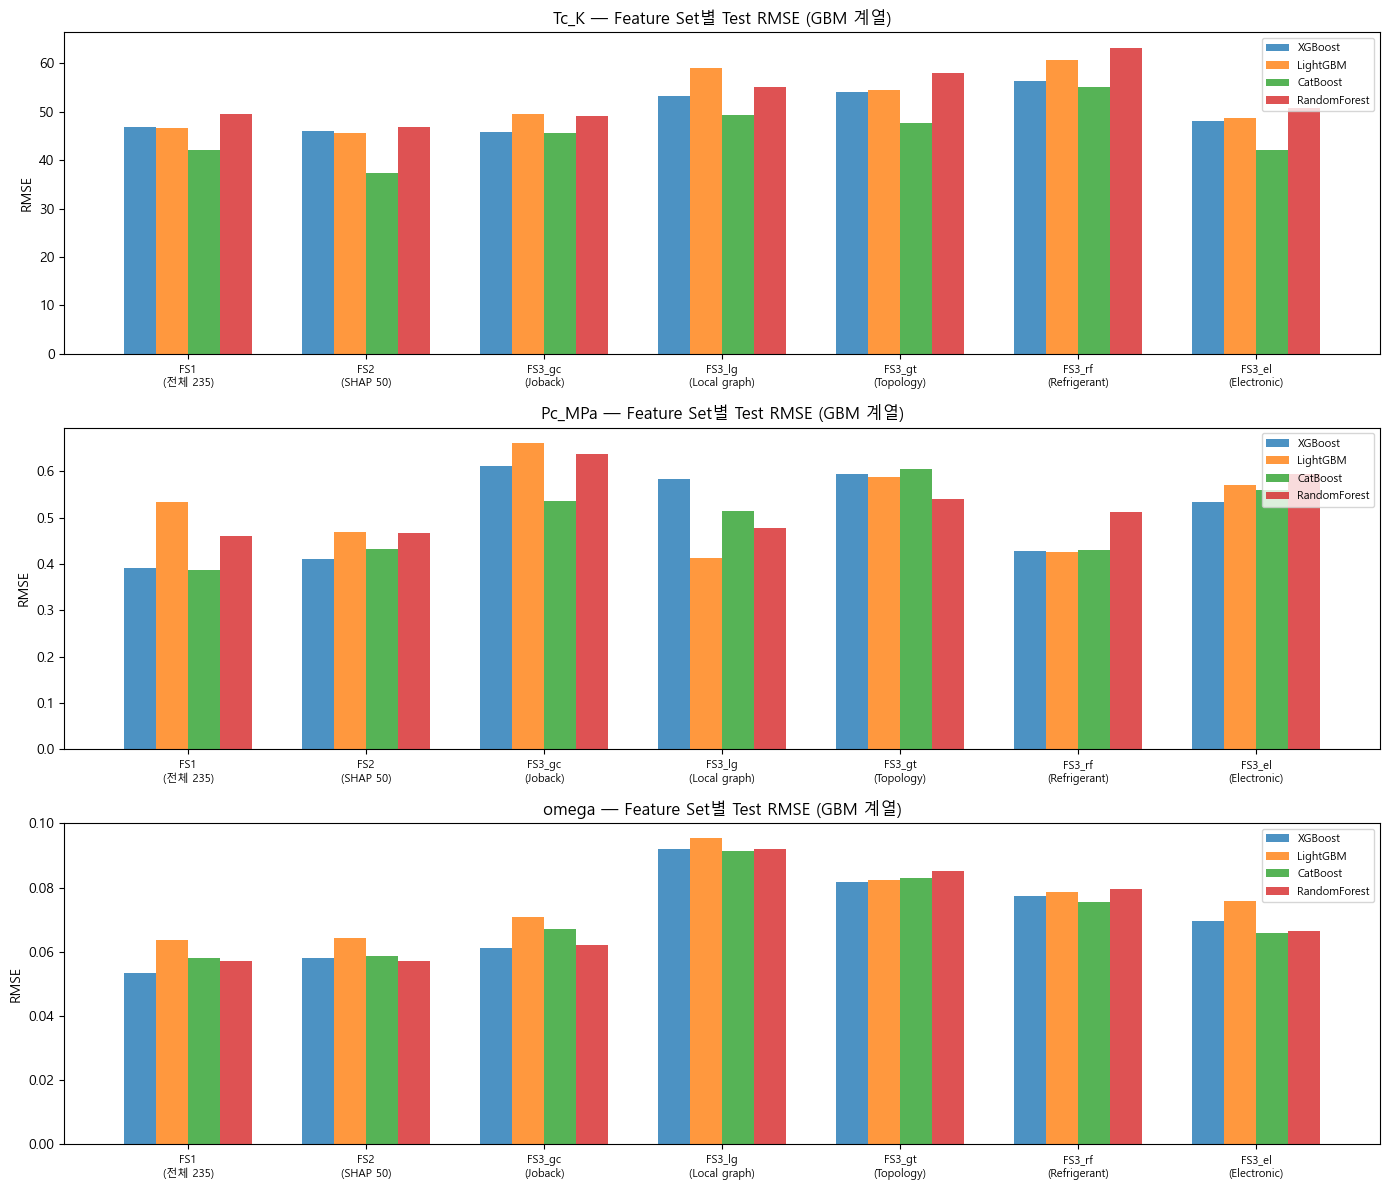

In [36]:

# FS 순서 정의
FS_ORDER = ['FS1', 'FS2', 'FS3_gc', 'FS3_lg', 'FS3_gt', 'FS3_rf', 'FS3_el']
FS_LABELS = {
    'FS1':    'FS1\n(전체 235)',
    'FS2':    'FS2\n(SHAP 50)',
    'FS3_gc': 'FS3_gc\n(Joback)',
    'FS3_lg': 'FS3_lg\n(Local graph)',
    'FS3_gt': 'FS3_gt\n(Topology)',
    'FS3_rf': 'FS3_rf\n(Refrigerant)',
    'FS3_el': 'FS3_el\n(Electronic)',
}

# GBM 계열만 (가장 안정적)
gbm_models = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 12))

for ax, tgt in zip(axes, TARGETS):
    sub = test[test['target'] == tgt]
    x = np.arange(len(FS_ORDER))
    w = 0.18
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

    for i, m in enumerate(gbm_models):
        m_sub = sub[sub['model'] == m].set_index('fs')
        vals = [m_sub.loc[fs, 'rmse'] if fs in m_sub.index else np.nan for fs in FS_ORDER]
        ax.bar(x + (i - 1.5) * w, vals, w, label=m, color=colors[i], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([FS_LABELS[f] for f in FS_ORDER], fontsize=8)
    ax.set_title(f'{tgt} — Feature Set별 Test RMSE (GBM 계열)')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_fs_ablation_rmse.png', dpi=150)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1896\3341323843.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='model', columns='fs', values='rmse')


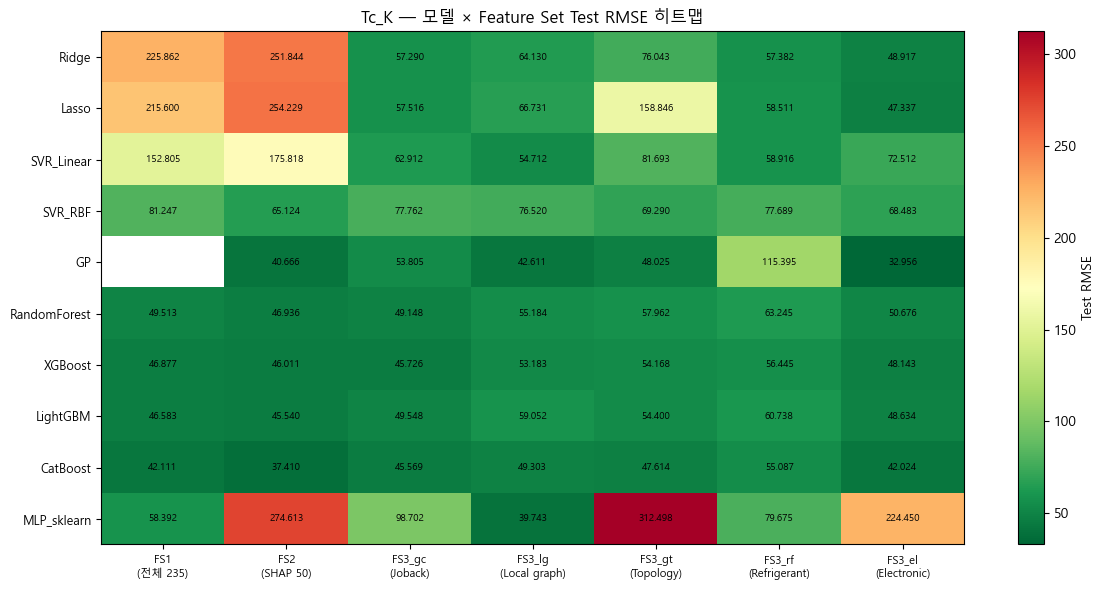

C:\Users\user\AppData\Local\Temp\ipykernel_1896\3341323843.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='model', columns='fs', values='rmse')


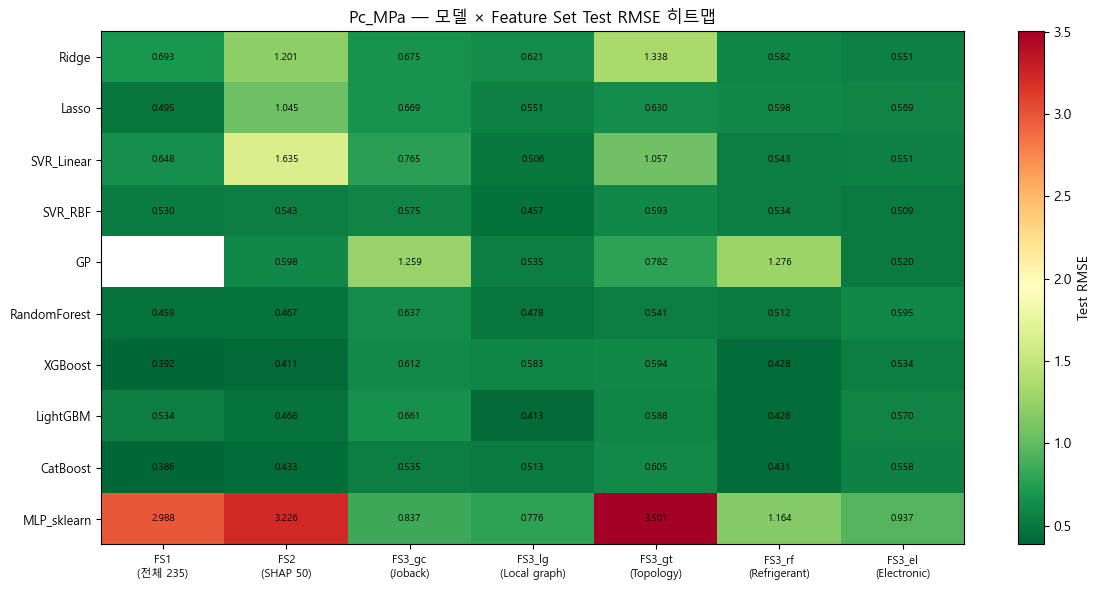

C:\Users\user\AppData\Local\Temp\ipykernel_1896\3341323843.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='model', columns='fs', values='rmse')


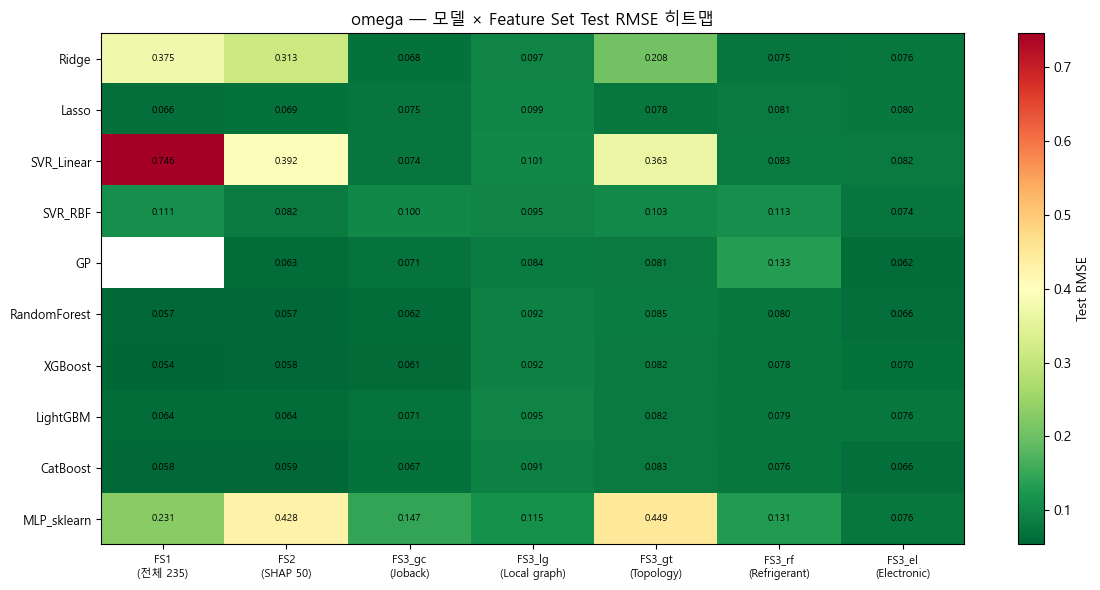

In [37]:
# 전체 모델 × FS별 Test RMSE 히트맵 (타겟별)
import matplotlib.colors as mcolors

for tgt in TARGETS:
    sub = test[test['target'] == tgt]
    pivot = sub.pivot_table(index='model', columns='fs', values='rmse')
    pivot = pivot.reindex(index=[m for m in MODEL_ORDER if m in pivot.index],
                          columns=[f for f in FS_ORDER if f in pivot.columns])

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
    plt.colorbar(im, ax=ax, label='Test RMSE')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([FS_LABELS.get(f, f) for f in pivot.columns], fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(f'{tgt} — 모델 × Feature Set Test RMSE 히트맵')

    # 셀 값 표시
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=7, color='black')

    fig.tight_layout()
    fig.savefig(RESULTS / 'plots' / f'phase1_heatmap_{tgt}.png', dpi=150)
    plt.show()

In [38]:
# FS2 사용 모델에서 FS1→FS2 RMSE 변화율
models_with_both = [m for m in MODEL_ORDER if m not in ('GP', 'MLP_sklearn')]

rows = []
for m in models_with_both:
    for tgt in TARGETS:
        t1 = test[(test['model'] == m) & (test['fs'] == 'FS1') & (test['target'] == tgt)]
        t2 = test[(test['model'] == m) & (test['fs'] == 'FS2') & (test['target'] == tgt)]
        if t1.empty or t2.empty:
            continue
        r1 = t1.iloc[0]['rmse']
        r2 = t2.iloc[0]['rmse']
        rows.append({'model': m, 'target': tgt,
                     'rmse_FS1': round(r1,4), 'rmse_FS2': round(r2,4),
                     'delta_pct': round((r2 - r1) / r1 * 100, 1)})

delta_df = pd.DataFrame(rows)
print('FS1 → FS2 Test RMSE 변화율 (음수 = 개선)')
print(delta_df.to_string(index=False))

FS1 → FS2 Test RMSE 변화율 (음수 = 개선)
       model target  rmse_FS1  rmse_FS2  delta_pct
       Ridge   Tc_K  225.8621  251.8444       11.5
       Ridge Pc_MPa    0.6926    1.2014       73.5
       Ridge  omega    0.3754    0.3128      -16.7
       Lasso   Tc_K  215.6005  254.2291       17.9
       Lasso Pc_MPa    0.4953    1.0449      110.9
       Lasso  omega    0.0656    0.0686        4.6
  SVR_Linear   Tc_K  152.8045  175.8184       15.1
  SVR_Linear Pc_MPa    0.6481    1.6354      152.3
  SVR_Linear  omega    0.7463    0.3925      -47.4
     SVR_RBF   Tc_K   81.2466   65.1243      -19.8
     SVR_RBF Pc_MPa    0.5298    0.5432        2.5
     SVR_RBF  omega    0.1106    0.0821      -25.8
RandomForest   Tc_K   49.5126   46.9356       -5.2
RandomForest Pc_MPa    0.4592    0.4675        1.8
RandomForest  omega    0.0572    0.0572       -0.1
     XGBoost   Tc_K   46.8768   46.0109       -1.8
     XGBoost Pc_MPa    0.3921    0.4106        4.7
     XGBoost  omega    0.0536    0.0581        8

## 10. omega MAPE 이슈 분석

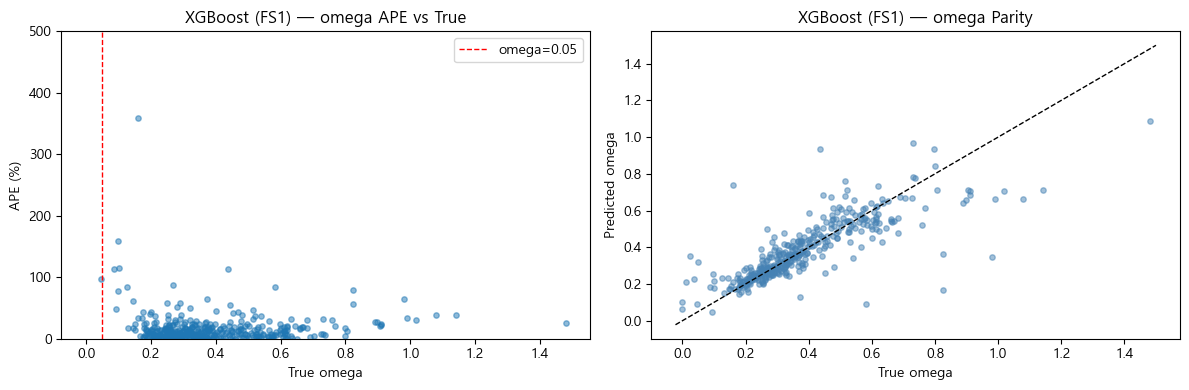

omega < 0.05 화합물: 7개,  mean APE = 2738.2%
omega >= 0.05 화합물: 380개,  mean APE = 16.5%


In [15]:
# omega 최고 모델 OOF 분석
best_m, best_fs = best_combos['omega']
json_path = RESULTS / 'cv_scores' / f'{best_m}_{best_fs}_omega.json'
with open(json_path) as f:
    res = json.load(f)

y_true = np.array(res['oof_true'])
y_pred = np.array(res['oof_pred'])
ape = np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8)) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_true, ape, alpha=0.5, s=15)
axes[0].set_xlabel('True omega')
axes[0].set_ylabel('APE (%)')
axes[0].set_ylim(0, min(ape.max(), 500))
axes[0].axvline(0.05, color='r', ls='--', lw=1, label='omega=0.05')
axes[0].set_title(f'{best_m} ({best_fs}) — omega APE vs True')
axes[0].legend()

axes[1].scatter(y_true, y_pred, alpha=0.5, s=15, color='steelblue')
lim = (y_true.min()-0.02, y_true.max()+0.02)
axes[1].plot(lim, lim, 'k--', lw=1)
axes[1].set_xlabel('True omega')
axes[1].set_ylabel('Predicted omega')
axes[1].set_title(f'{best_m} ({best_fs}) — omega Parity')

plt.tight_layout()
plt.savefig(RESULTS / 'plots' / 'phase1_omega_analysis.png', dpi=150)
plt.show()

print(f'omega < 0.05 화합물: {(y_true < 0.05).sum()}개,  mean APE = {ape[y_true < 0.05].mean():.1f}%')
print(f'omega >= 0.05 화합물: {(y_true >= 0.05).sum()}개,  mean APE = {ape[y_true >= 0.05].mean():.1f}%')